# Task 2 Demo

This notebook shows:
- dataset overview
- training process from saved artifacts
- confusion matrix
- standalone CNN and NER examples
- integration tests via verify_claim


In [1]:
from pathlib import Path
import sys
import json
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

cwd = Path.cwd().resolve()
if (cwd / 'task2').exists():
    repo_root = cwd
    task2_root = cwd / 'task2'
elif cwd.name == 'task2':
    repo_root = cwd.parent
    task2_root = cwd
else:
    raise RuntimeError('Run this notebook from repo root or task2 directory')

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from task2.image_classification.infer_image import predict_image
from task2.ner.infer_ner import extract_animal_from_text
from task2.pipeline.verify_claim import verify_claim

CNN_MODEL = task2_root / 'image_classification' / 'models' / 'ANIMAL_CLF.keras'
CLASS_NAMES = task2_root / 'image_classification' / 'artifacts' / 'class_names.json'
HISTORY = task2_root / 'image_classification' / 'artifacts' / 'history.json'
CONF_MAT = task2_root / 'image_classification' / 'artifacts' / 'confusion_matrix.png'
DATA_DIR = task2_root / 'image_classification' / 'data' / 'raw-img'
NER_MODEL = task2_root / 'ner' / 'model'

required = [CNN_MODEL, CLASS_NAMES, HISTORY, CONF_MAT, DATA_DIR, NER_MODEL]
missing = [str(p) for p in required if not p.exists()]
if missing:
    raise FileNotFoundError('Missing paths:\n' + '\n'.join(missing))

with open(CLASS_NAMES, 'r', encoding='utf-8') as f:
    class_names = json.load(f)

print('Task2 root:', task2_root)
print('Classes:', class_names)


C:\Users\nikit\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Task2 root: C:\Users\nikit\Python projects\winstars-ai-ds-internship-test\task2
Classes: ['butterfly', 'cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'sheep', 'spyder', 'squirrel']


## 1) Dataset overview


Total images: 26179
butterfly   : 2112
cat         : 1668
chicken     : 3098
cow         : 1866
dog         : 4863
elephant    : 1446
horse       : 2623
sheep       : 1820
spyder      : 4821
squirrel    : 1862


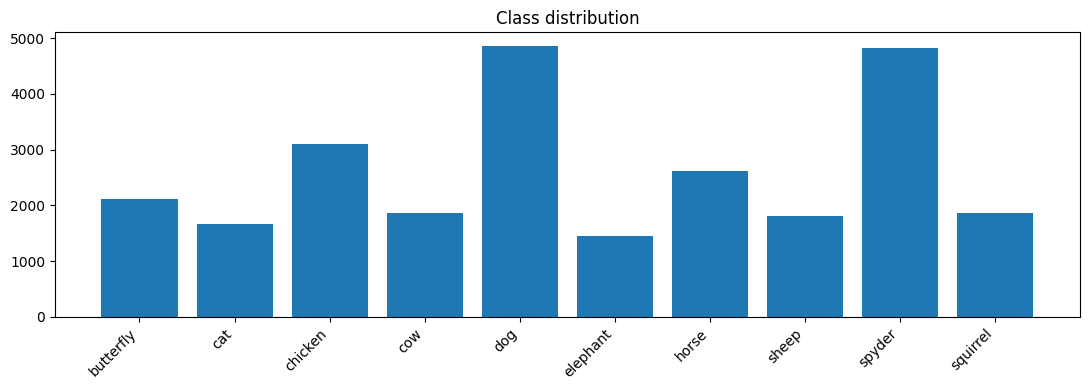

In [2]:
def is_image(p: Path) -> bool:
    return p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp'}

counts = {}
for cls in class_names:
    imgs = [p for p in (DATA_DIR / cls).iterdir() if p.is_file() and is_image(p)]
    counts[cls] = len(imgs)

print('Total images:', sum(counts.values()))
for cls in class_names:
    print(f'{cls:12s}: {counts[cls]}')

plt.figure(figsize=(11, 4))
plt.bar(list(counts.keys()), list(counts.values()))
plt.xticks(rotation=45, ha='right')
plt.title('Class distribution')
plt.tight_layout()
plt.show()


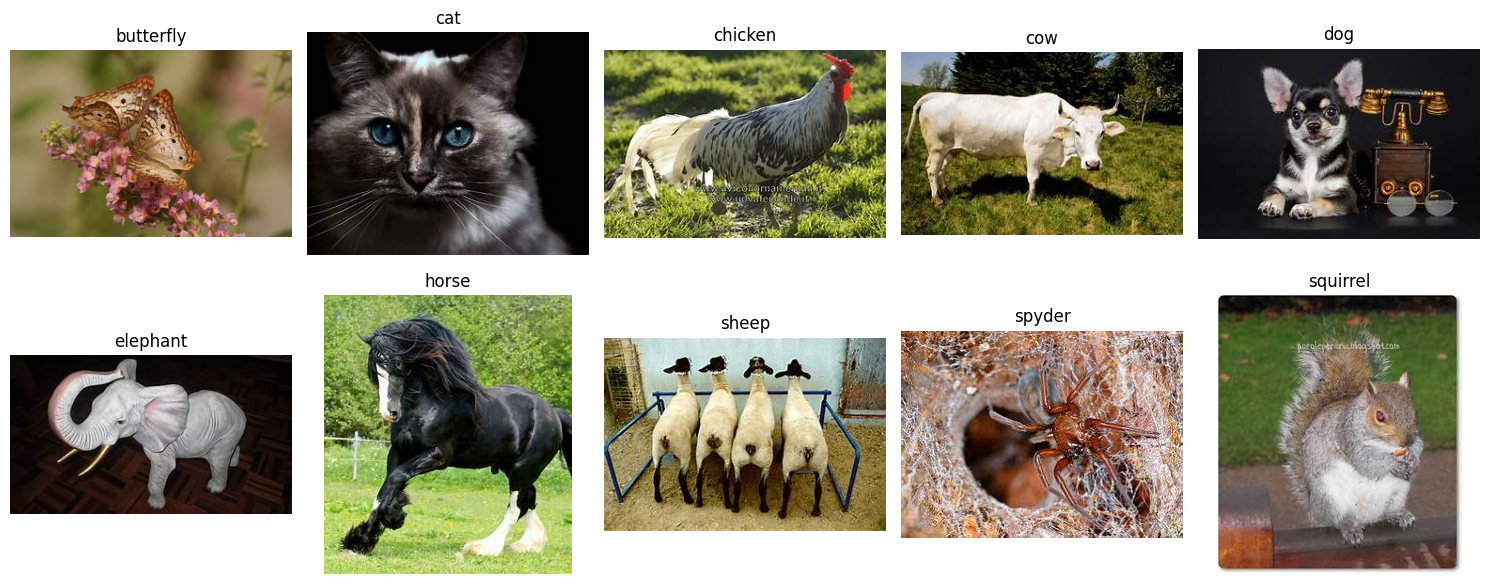

In [3]:
random.seed(42)
samples = []
for cls in class_names:
    imgs = [p for p in (DATA_DIR / cls).iterdir() if p.is_file() and is_image(p)]
    samples.append((cls, random.choice(imgs)))

cols = 5
rows = int(np.ceil(len(samples) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
axes = np.array(axes).reshape(rows, cols)

for i, (cls, path) in enumerate(samples):
    r, c = divmod(i, cols)
    axes[r, c].imshow(Image.open(path).convert('RGB'))
    axes[r, c].set_title(cls)
    axes[r, c].axis('off')

for j in range(len(samples), rows * cols):
    r, c = divmod(j, cols)
    axes[r, c].axis('off')

plt.tight_layout()
plt.show()


## 2) Training process from saved history


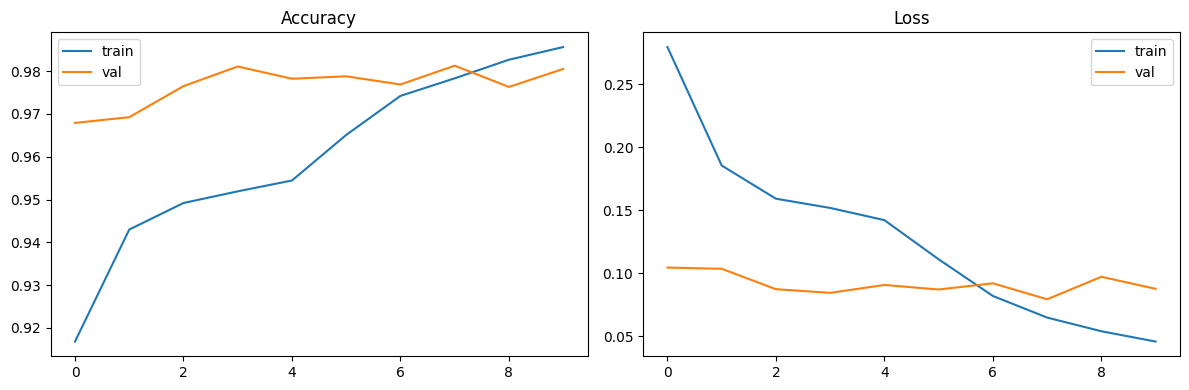

In [4]:
with open(HISTORY, 'r', encoding='utf-8') as f:
    hist = json.load(f)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
if 'accuracy' in hist: ax[0].plot(hist['accuracy'], label='train')
if 'val_accuracy' in hist: ax[0].plot(hist['val_accuracy'], label='val')
ax[0].set_title('Accuracy')
ax[0].legend()
if 'loss' in hist: ax[1].plot(hist['loss'], label='train')
if 'val_loss' in hist: ax[1].plot(hist['val_loss'], label='val')
ax[1].set_title('Loss')
ax[1].legend()
plt.tight_layout()
plt.show()


## 3) Confusion matrix


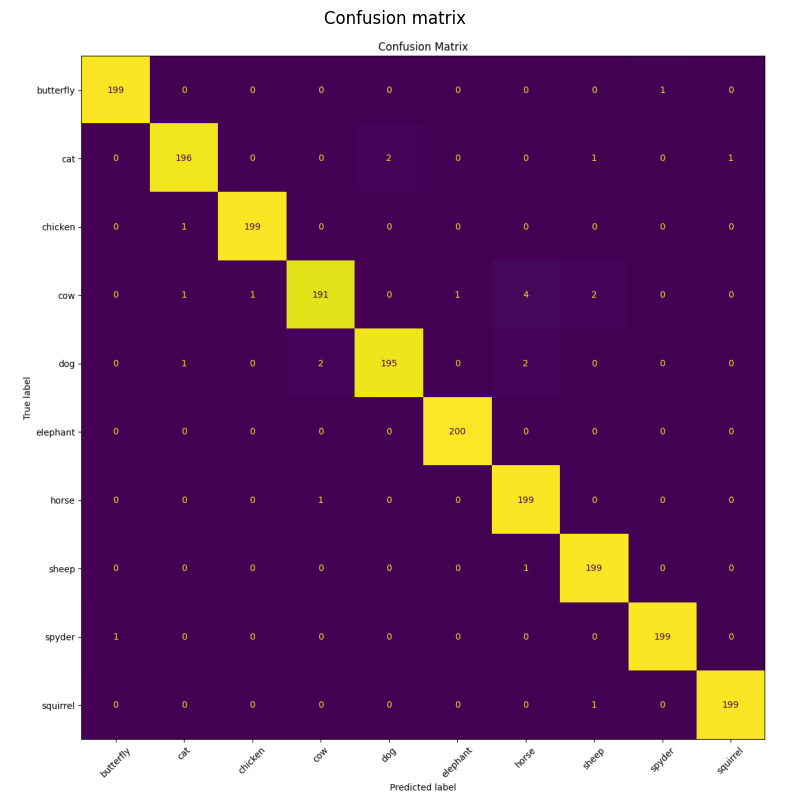

In [5]:
plt.figure(figsize=(10, 10))
plt.imshow(Image.open(CONF_MAT))
plt.axis('off')
plt.title('Confusion matrix')
plt.show()


## 4) Standalone examples

In [ ]:
for cls in class_names[:3]:
    image_path = random.choice([p for p in (DATA_DIR / cls).iterdir() if p.is_file() and is_image(p)])
    res = predict_image(image_path, CNN_MODEL, CLASS_NAMES)
    print('True:', cls, '| Pred:', res['prediction'], '| Conf:', round(res['confidence'], 4))
    print('Top-3:', res['top_predictions'])
    print('-' * 80)


True: butterfly | Pred: butterfly | Conf: 1.0
Top-3: [{'label': 'butterfly', 'score': 0.9999994039535522}, {'label': 'spyder', 'score': 5.925330697209574e-07}, {'label': 'horse', 'score': 1.2985108988061711e-08}]
--------------------------------------------------------------------------------
True: cat | Pred: cat | Conf: 0.9994
Top-3: [{'label': 'cat', 'score': 0.9993898868560791}, {'label': 'dog', 'score': 0.0004962608218193054}, {'label': 'squirrel', 'score': 0.00011278547754045576}]
--------------------------------------------------------------------------------
True: chicken | Pred: chicken | Conf: 1.0
Top-3: [{'label': 'chicken', 'score': 1.0}, {'label': 'sheep', 'score': 6.472987423844501e-11}, {'label': 'spyder', 'score': 1.3101426193928845e-11}]
--------------------------------------------------------------------------------


In [ ]:
texts = [
    'There is a cow in the photo.',
    'A butterfly is on a flower.',
    'No animal is mentioned here.'
]

for t in texts:
    print(extract_animal_from_text(t, NER_MODEL))


Loading weights: 100%|в–€в–€в–€в–€в–€в–€в–€в–€в–€в–€| 102/102 [00:00<00:00, 734.07it/s, Materializing param=distilbert.transformer.layer.5.sa_layer_norm.weight]    


{'text': 'There is a cow in the photo.', 'animal': 'cow', 'raw_entities': [{'entity_group': 'ANIMAL', 'score': np.float32(0.9994597), 'word': 'cow', 'start': 11, 'end': 14}]}


Loading weights: 100%|в–€в–€в–€в–€в–€в–€в–€в–€в–€в–€| 102/102 [00:00<00:00, 555.44it/s, Materializing param=distilbert.transformer.layer.5.sa_layer_norm.weight]    


{'text': 'A butterfly is on a flower.', 'animal': 'butterfly', 'raw_entities': [{'entity_group': 'ANIMAL', 'score': np.float32(0.99899584), 'word': 'butterfly', 'start': 2, 'end': 11}]}


Loading weights: 100%|в–€в–€в–€в–€в–€в–€в–€в–€в–€в–€| 102/102 [00:00<00:00, 522.06it/s, Materializing param=distilbert.transformer.layer.5.sa_layer_norm.weight]    


{'text': 'No animal is mentioned here.', 'animal': None, 'raw_entities': [{'entity_group': 'ANIMAL', 'score': np.float32(0.96385795), 'word': 'animal', 'start': 3, 'end': 9}]}


## 5) verify_claim integration tests

In [ ]:
tests = [
    ('cat', 'There is a cat in this photo.'),
    ('dog', 'There is a cat in this photo.'),
    ('horse', 'There is a horse in this photo.')
]

for cls, text in tests:
    image_path = random.choice([p for p in (DATA_DIR / cls).iterdir() if p.is_file() and is_image(p)])
    out = verify_claim(
        image_path=image_path,
        text=text,
        cnn_model=CNN_MODEL,
        class_names=CLASS_NAMES,
        ner_model_dir=NER_MODEL,
        threshold=0.5,
    )
    print('Image class:', cls, '| Text:', text)
    print(out["match"])
    print('=' * 100)


Loading weights: 100%|██████████| 102/102 [00:00<00:00, 849.76it/s, Materializing param=distilbert.transformer.layer.5.sa_layer_norm.weight]    


Image class: cat | Text: There is a cat in this photo.
True


Loading weights: 100%|██████████| 102/102 [00:00<00:00, 794.70it/s, Materializing param=distilbert.transformer.layer.5.sa_layer_norm.weight]    


Image class: dog | Text: There is a cat in this photo.
False


Loading weights: 100%|██████████| 102/102 [00:00<00:00, 716.92it/s, Materializing param=distilbert.transformer.layer.5.sa_layer_norm.weight]    


Image class: horse | Text: There is a horse in this photo.
True


## Conclusions


- The classifier captures class-level patterns reasonably well, but confusion still exists for visually similar animals.
- Reviewing misclassified images is critical to understand failure modes and guide augmentation or data-cleaning improvements.
- NER extraction and image classification can be combined into a practical claim-verification pipeline.
- End-to-end checks in `verify_claim` are useful to validate both individual models and their integration behavior.